# Accumulator Probe — Full Self-Contained Run

Fully self-contained. Runs everything from scratch:
- 6 perturbation strategies → probes → plots
- Cross-language generalization (Java, C++, C, C#, JS, PHP)
- Multi-model comparison
- Cross-model transfer matrix
- CSV save

**BFloat16 fix applied throughout** (`.cpu().float().numpy()`).

In [6]:
import torch, numpy as np, matplotlib.pyplot as plt, re, ast, os, json, random, string, csv
import keyword, builtins, warnings
from collections import defaultdict
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModel
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from numpy.linalg import norm
warnings.filterwarnings('ignore')

DEVICE      = 'cuda' if torch.cuda.is_available() else 'cpu'
RESULTS_DIR = '../results/accumulator'
os.makedirs(RESULTS_DIR, exist_ok=True)
print(f'Device: {DEVICE}  |  Results: {RESULTS_DIR}')

Device: cpu  |  Results: ../results/accumulator


## Model

In [7]:
MODEL_NAME = 'Qwen/Qwen2.5-1.5B'
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModel.from_pretrained(MODEL_NAME, output_hidden_states=True, trust_remote_code=True)
model.eval().to(DEVICE)

NUM_LAYERS  = model.config.num_hidden_layers
HIDDEN_SIZE = model.config.hidden_size
_probe_ids      = tokenizer('x', return_tensors='pt')['input_ids'][0].tolist()
LEADING_SPECIAL = len(_probe_ids) - len(tokenizer.tokenize('x'))
print(f'Layers={NUM_LAYERS}  Hidden={HIDDEN_SIZE}  LeadingSpecial={LEADING_SPECIAL}')

Loading weights: 100%|██████████| 338/338 [00:00<00:00, 6599.51it/s]

Layers=28  Hidden=1536  LeadingSpecial=0


## Data

In [8]:
XLCOST_ROOT  = '/Applications/Projects/Algoverse/Coding/XLCoST_data'
NL2CODE_PROG = os.path.join(XLCOST_ROOT, 'retrieval', 'nl2code_search', 'program_level')

def reconstruct_code(tokens):
    indent, lines, cur = 0, [], []
    for t in tokens:
        if t == 'NEW_LINE':  lines.append('    '*indent + ' '.join(cur)); cur = []
        elif t == 'INDENT':  indent += 1
        elif t == 'DEDENT':  indent = max(0, indent-1)
        else:                cur.append(t)
    if cur: lines.append('    '*indent + ' '.join(cur))
    return '\n'.join(lines).strip()

def load_programs(lang, split='train', n=500):
    path = os.path.join(NL2CODE_PROG, lang, f'{split}.jsonl')
    if not os.path.exists(path): raise FileNotFoundError(path)
    progs = []
    with open(path) as f:
        for line in f:
            if len(progs) >= n: break
            rec  = json.loads(line)
            toks = rec.get('code_tokens', rec.get('docstring_tokens', []))
            if toks: progs.append(reconstruct_code(toks))
    return progs

RAW_PROGRAMS = load_programs('Python', n=500)
print(f'Loaded {len(RAW_PROGRAMS)} Python programs')

Loaded 500 Python programs


## Core Functions

In [9]:
PYTHON_PROTECTED = set(keyword.kwlist) | set(dir(builtins)) | {'self','cls','None','True','False'}

def get_accumulator_names(code):
    """Variables that are AugAssign targets or .append/.extend targets inside a loop."""
    accumulators = set()
    try: tree = ast.parse(code)
    except SyntaxError: return accumulators

    loop_vars = set()
    for node in ast.walk(tree):
        if isinstance(node, ast.For):
            for n in ast.walk(node.target):
                if isinstance(n, ast.Name): loop_vars.add(n.id)

    index_names = set()
    for node in ast.walk(tree):
        if isinstance(node, ast.Subscript):
            slc = node.slice
            if isinstance(slc, ast.Index): slc = slc.value
            if isinstance(slc, ast.Name): index_names.add(slc.id)

    _APPEND = {'append','extend','add','update'}
    for node in ast.walk(tree):
        if not isinstance(node, (ast.For, ast.While)): continue
        for stmt in ast.walk(node):
            if isinstance(stmt, ast.AugAssign) and isinstance(stmt.target, ast.Name):
                n = stmt.target.id
                if n not in loop_vars and n not in index_names and n != '_':
                    accumulators.add(n)
            elif (isinstance(stmt, ast.Expr) and isinstance(stmt.value, ast.Call)
                  and isinstance(stmt.value.func, ast.Attribute)
                  and stmt.value.func.attr in _APPEND
                  and isinstance(stmt.value.func.value, ast.Name)):
                n = stmt.value.func.value.id
                if n not in loop_vars and n not in index_names and n != '_':
                    accumulators.add(n)
    return accumulators


def label_tokens(code, target_names):
    if not target_names: return [], []
    tokens, labels = tokenizer.tokenize(code), []
    for tok in tokens:
        clean   = tok.lstrip('Ġ▁Ā').lstrip('##')
        matched = not tok.startswith('##') and (clean in target_names or clean.strip('[]().,;:') in target_names)
        labels.append(1 if matched else 0)
    return tokens, labels


def collect_all_identifiers(code):
    names = set()
    try:
        tree = ast.parse(code)
        for node in ast.walk(tree):
            if isinstance(node, ast.Name): names.add(node.id)
            elif isinstance(node, (ast.FunctionDef, ast.AsyncFunctionDef, ast.ClassDef)): names.add(node.name)
            elif isinstance(node, ast.arg): names.add(node.arg)
    except SyntaxError:
        for m in re.finditer(r'\b([a-zA-Z_]\w*)\b', code): names.add(m.group(1))
    return names - PYTHON_PROTECTED


def apply_rename_map(code, rmap):
    for old in sorted(rmap, key=len, reverse=True):
        code = re.sub(r'\b' + re.escape(old) + r'\b', rmap[old], code)
    return code


MAX_SEQ_LEN = 512

def extract_hidden_states(dataset):
    all_hidden, all_labels, all_toks = defaultdict(list), [], []
    with torch.no_grad():
        for s in tqdm(dataset, desc='Extracting hidden states', leave=True):
            enc = tokenizer(s['code'], return_tensors='pt', truncation=True,
                            max_length=MAX_SEQ_LEN, padding=False).to(DEVICE)
            enc_len      = enc['input_ids'].shape[1] - LEADING_SPECIAL
            labels_trunc = s['labels'][:enc_len]
            for li, hs in enumerate(model(**enc).hidden_states):
                # .float() required — Qwen outputs BFloat16 which numpy cannot handle
                all_hidden[li].extend(hs[0, LEADING_SPECIAL:LEADING_SPECIAL+len(labels_trunc)].cpu().float().numpy())
            all_labels.extend(labels_trunc)
            all_toks.extend(s['tokens'][:enc_len])
    return {k: np.array(v) for k,v in all_hidden.items()}, np.array(all_labels), all_toks


def train_probes(hidden_by_layer, labels, test_size=0.2, rs=42):
    n = len(labels)
    tr, te = train_test_split(np.arange(n), test_size=test_size, random_state=rs, stratify=labels)
    results = {}
    for li in tqdm(sorted(hidden_by_layer), desc='Training probes', leave=True):
        X = hidden_by_layer[li]
        clf = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=rs, C=1.0)
        clf.fit(X[tr], labels[tr])
        results[li] = {
            'probe':     clf,
            'train_acc': accuracy_score(labels[tr], clf.predict(X[tr])),
            'test_acc':  accuracy_score(labels[te], clf.predict(X[te])),
            'train_f1':  f1_score(labels[tr], clf.predict(X[tr]),  average='macro', zero_division=0),
            'test_f1':   f1_score(labels[te], clf.predict(X[te]),  average='macro', zero_division=0),
            'test_idx':  te,
        }
    return results


def build_dataset(programs, perturb_fn=None):
    dataset, skipped = [], 0
    for idx, code in enumerate(programs):
        new_code, new_acc = (code, get_accumulator_names(code)) if perturb_fn is None else perturb_fn(code, seed=idx)
        if not new_acc: skipped += 1; continue
        toks, labs = label_tokens(new_code, new_acc)
        if not toks or sum(labs) == 0: skipped += 1; continue
        dataset.append({'code': new_code, 'tokens': toks, 'labels': labs, 'target_names': new_acc})
    pos = sum(sum(d['labels']) for d in dataset)
    tok = sum(len(d['tokens']) for d in dataset)
    print(f'  {len(dataset)} programs  |  {pos:,} pos / {tok:,} tokens ({100*pos/tok:.1f}%)  |  {skipped} skipped')
    return dataset

print('Core functions defined.')

Core functions defined.


## Perturbation Strategies

In [10]:
RANDOM_NOUNS = sorted({'apple','bag','ball','basil','bear','bed','belt','birch','bird','bolt',
    'bowl','box','broom','brush','cage','cart','cat','cedar','clip','coat','coin','comb','cord',
    'crow','cube','cup','deer','desk','dial','dish','dog','dome','drop','drum','duck','dust',
    'edge','fern','fish','flame','fork','fox','frog','gate','gear','gem','glove','glow','grain',
    'grid','hat','hawk','heap','hill','hole','hook','hose','hull','jar','kelp','knob','knot',
    'lamb','lamp','latch','leaf','lens','lion','lobe','lock','loop','lump','maple','mark','mast',
    'mesh','mint','mist','mold','mole','moss','nail','net','newt','node','oak','orb','palm',
    'path','peak','pen','pile','pine','pipe','plank','plate','plug','pool','port','pot','puma',
    'ramp','reed','reef','ring','rod','root','rope','rose','rug','sage','sand','seal','seed',
    'slab','slot','stem','tree','vine','wolf'})

ACCUM_NAMES = ['total','count','result','output','answer','value','amount','data','temp','buf',
               'res','ret','score','maximum','minimum','current','previous','running',
               'accumulator','product','difference','sumval','tally','aggregate']
INDEX_NAMES = ['i','j','k','n','m','idx','pos','key','ptr','cur','row','col','x','y','p','q','r','t','u']

def _renameable(code):
    return sorted(n for n in collect_all_identifiers(code) if n not in PYTHON_PROTECTED)

def perturb_random_nouns(code, seed=0):
    rng = random.Random(seed); names = _renameable(code)
    pool = rng.sample(RANDOM_NOUNS, min(len(RANDOM_NOUNS), len(names)))
    if len(names) > len(pool): pool += rng.choices(RANDOM_NOUNS, k=len(names)-len(pool))
    new_code = apply_rename_map(code, dict(zip(names, pool)))
    return new_code, get_accumulator_names(new_code)

def perturb_single_chars(code, seed=0):
    rng = random.Random(seed); names = _renameable(code)
    pool = (list(string.ascii_lowercase) + [c+str(i) for i in range(10) for c in string.ascii_lowercase])[:len(names)]
    rng.shuffle(pool)
    new_code = apply_rename_map(code, dict(zip(names, pool)))
    return new_code, get_accumulator_names(new_code)

def perturb_all_same(code, seed=0):
    new_code = apply_rename_map(code, {n: 'x' for n in _renameable(code)})
    return new_code, get_accumulator_names(new_code)

def perturb_numeric_vars(code, seed=0):
    rng = random.Random(seed); names = _renameable(code)
    idxs = list(range(1, len(names)+1)); rng.shuffle(idxs)
    new_code = apply_rename_map(code, {n: f'v{i}' for n,i in zip(names, idxs)})
    return new_code, get_accumulator_names(new_code)

def perturb_misleading(code, seed=0):
    rng = random.Random(seed); all_n = _renameable(code); acc_n = get_accumulator_names(code)
    acc_v  = sorted(n for n in all_n if n in acc_n)
    norm_v = sorted(n for n in all_n if n not in acc_n)
    ip = (INDEX_NAMES * (len(acc_v)  // len(INDEX_NAMES) + 2)); rng.shuffle(ip)
    ap = (ACCUM_NAMES * (len(norm_v) // len(ACCUM_NAMES) + 2)); rng.shuffle(ap)
    rmap = {v: ip[i] for i,v in enumerate(acc_v)}
    rmap.update({v: ap[i] for i,v in enumerate(norm_v)})
    new_code = apply_rename_map(code, rmap)
    return new_code, get_accumulator_names(new_code)

PERTURBATIONS = {
    'baseline':     None,
    'random_nouns': perturb_random_nouns,
    'single_chars': perturb_single_chars,
    'all_same':     perturb_all_same,
    'numeric_vars': perturb_numeric_vars,
    'misleading':   perturb_misleading,
}
print('Perturbation strategies defined:', list(PERTURBATIONS.keys()))

Perturbation strategies defined: ['baseline', 'random_nouns', 'single_chars', 'all_same', 'numeric_vars', 'misleading']


## Run All Perturbations

In [11]:
import pickle

CKPT_DIR    = f'{RESULTS_DIR}/checkpoints'
CKPT_PROBES = f'{CKPT_DIR}/all_results.pkl'
CKPT_LABELS = f'{CKPT_DIR}/all_labels.pkl'
os.makedirs(CKPT_DIR, exist_ok=True)

all_results, all_hidden, all_labels = {}, {}, {}

if os.path.exists(CKPT_PROBES) and os.path.exists(CKPT_LABELS):
    with open(CKPT_PROBES, 'rb') as f: all_results = pickle.load(f)
    with open(CKPT_LABELS, 'rb') as f: all_labels  = pickle.load(f)
    layers = sorted(next(iter(all_results.values())).keys())
    print(f'Loaded checkpoint: {list(all_results.keys())}')
    print('Hidden states not cached — perturbation plots will re-run from probe weights only.')
else:
    for name, fn in PERTURBATIONS.items():
        print(f'\n{"="*55}  {name}')
        ds = build_dataset(RAW_PROGRAMS, perturb_fn=fn)
        if not ds: print('  No data — skipped'); continue
        h, lbs, _ = extract_hidden_states(ds)
        res = train_probes(h, lbs)
        all_results[name] = res
        all_hidden[name]  = h
        all_labels[name]  = lbs
        best_l = max(res, key=lambda l: res[l]['test_f1'])
        print(f'  Best → L{best_l}  acc={res[best_l]["test_acc"]:.3f}  f1={res[best_l]["test_f1"]:.3f}')

    layers = sorted(next(iter(all_results.values())).keys())

    with open(CKPT_PROBES, 'wb') as f: pickle.dump(all_results, f)
    with open(CKPT_LABELS, 'wb') as f: pickle.dump(all_labels,  f)
    print(f'\nCheckpoint saved → {CKPT_DIR}')

print(f'\nStrategies: {list(all_results.keys())}  |  Layers: {len(layers)}')


=======================================================  baseline
  181 programs  |  1,279 pos / 37,527 tokens (3.4%)  |  319 skipped


Training probes: 100%|██████████| 29/29 [09:45<00:00, 20.20s/it]


  Best → L9  acc=0.984  f1=0.893

=======================================================  random_nouns
  204 programs  |  1,498 pos / 40,594 tokens (3.7%)  |  296 skipped


Training probes: 100%|██████████| 29/29 [10:41<00:00, 22.14s/it]


  Best → L10  acc=0.979  f1=0.870

=======================================================  single_chars
  205 programs  |  1,563 pos / 40,066 tokens (3.9%)  |  295 skipped


...

  Best → L5  acc=0.986  f1=0.969

=======================================================  numeric_vars
  22 programs  |  90 pos / 5,065 tokens (1.8%)  |  478 skipped


Training probes: 100%|██████████| 29/29 [00:02<00:00, 10.51it/s]


  Best → L3  acc=0.999  f1=0.986

=======================================================  misleading
  204 programs  |  1,657 pos / 40,587 tokens (4.1%)  |  296 skipped


Training probes: 100%|██████████| 29/29 [06:25<00:00, 13.30s/it]

  Best → L9  acc=0.996  f1=0.972

Checkpoint saved → ../results/accumulator/checkpoints

Strategies: ['baseline', 'random_nouns', 'single_chars', 'all_same', 'numeric_vars', 'misleading']  |  Layers: 29


## Perturbation Plots

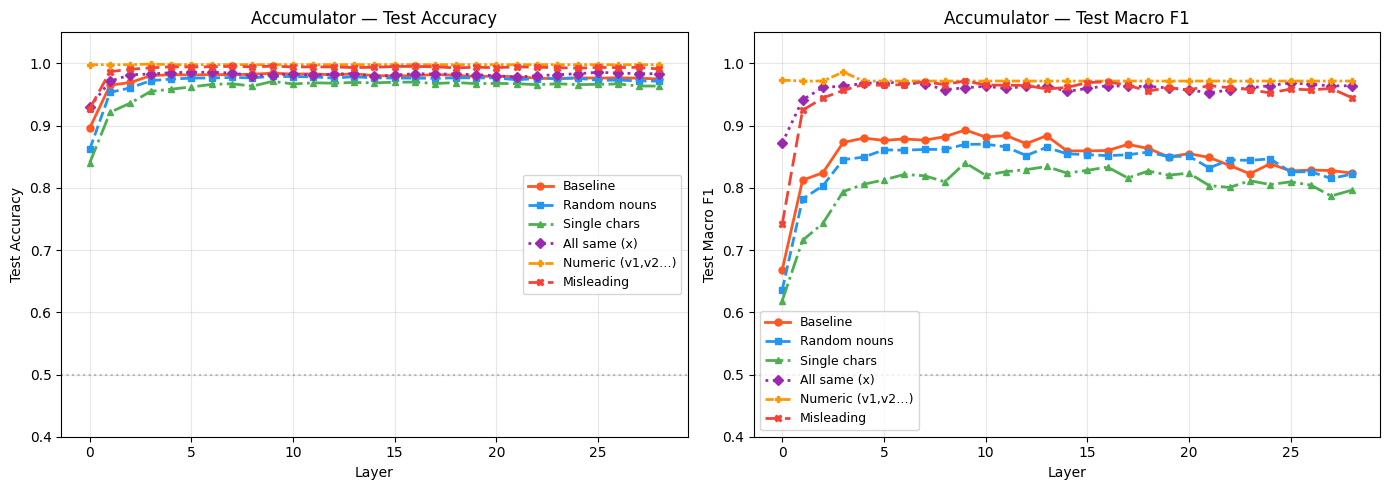

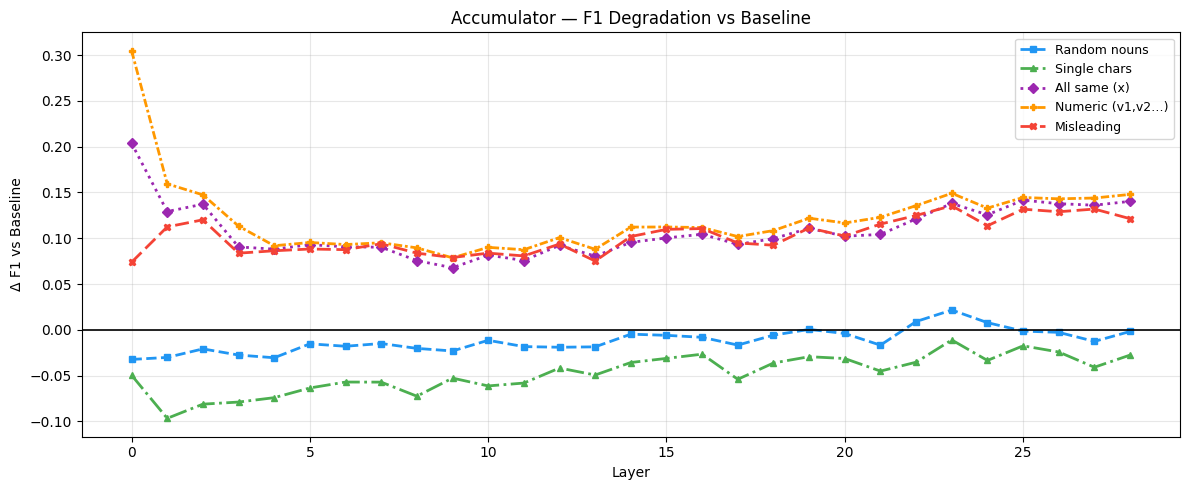

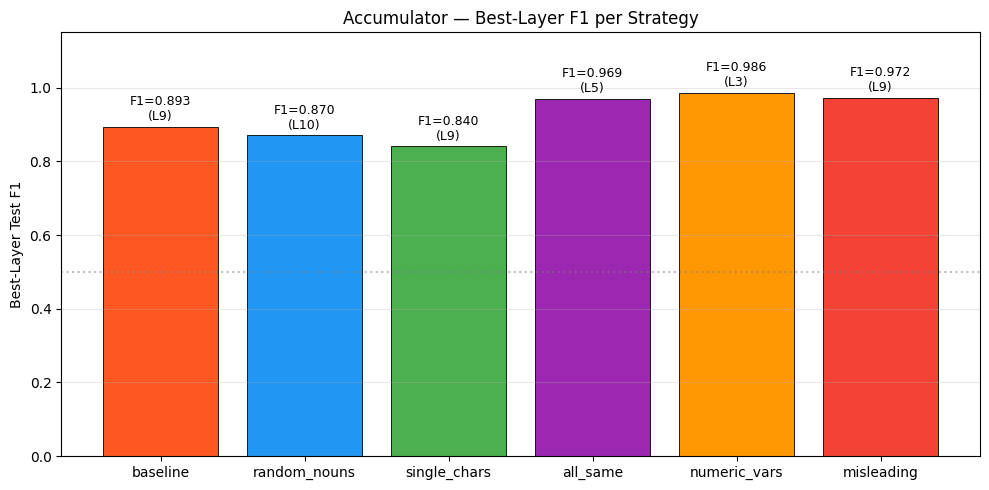

In [12]:
COLORS = {'baseline':'#FF5722','random_nouns':'#2196F3','single_chars':'#4CAF50',
          'all_same':'#9C27B0','numeric_vars':'#FF9800','misleading':'#F44336'}
MARKERS = {'baseline':'o','random_nouns':'s','single_chars':'^',
           'all_same':'D','numeric_vars':'P','misleading':'X'}
LSTYLES = {'baseline':'-','random_nouns':'--','single_chars':'-.',
           'all_same':':','numeric_vars':(0,(3,1,1,1)),'misleading':(0,(5,2))}
PLABELS = {'baseline':'Baseline','random_nouns':'Random nouns','single_chars':'Single chars',
           'all_same':'All same (x)','numeric_vars':'Numeric (v1,v2…)','misleading':'Misleading'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric, title in zip(axes, ['test_acc','test_f1'], ['Test Accuracy','Test Macro F1']):
    for s, res in all_results.items():
        ax.plot(layers, [res[l][metric] for l in layers],
                marker=MARKERS[s], color=COLORS[s], linestyle=LSTYLES[s],
                linewidth=2, markersize=5, label=PLABELS[s])
    ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5)
    ax.set_xlabel('Layer'); ax.set_ylabel(title); ax.set_ylim(0.4, 1.05)
    ax.set_title(f'Accumulator — {title}'); ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/probe_accuracy_f1_accumulator.png', dpi=150, bbox_inches='tight')
plt.show()

# Δ F1 vs baseline
base_f1_arr = np.array([all_results['baseline'][l]['test_f1'] for l in layers])
fig, ax = plt.subplots(figsize=(12, 5))
for s, res in all_results.items():
    if s == 'baseline': continue
    ax.plot(layers, np.array([res[l]['test_f1'] for l in layers]) - base_f1_arr,
            marker=MARKERS[s], color=COLORS[s], linestyle=LSTYLES[s],
            linewidth=2, markersize=5, label=PLABELS[s])
ax.axhline(0, color='black', linewidth=1.2)
ax.set_xlabel('Layer'); ax.set_ylabel('Δ F1 vs Baseline')
ax.set_title('Accumulator — F1 Degradation vs Baseline')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/delta_f1_accumulator.png', dpi=150, bbox_inches='tight')
plt.show()

# Best-layer bar chart
strats = list(all_results.keys())
best_f1s    = [max(all_results[s][l]['test_f1'] for l in layers) for s in strats]
best_layers = [max(all_results[s], key=lambda l: all_results[s][l]['test_f1']) for s in strats]
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(strats, best_f1s, color=[COLORS[s] for s in strats], edgecolor='black', linewidth=0.6)
for bar, f1, layer in zip(bars, best_f1s, best_layers):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'F1={f1:.3f}\n(L{layer})', ha='center', va='bottom', fontsize=9)
ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5)
ax.set_ylim(0, 1.15); ax.set_ylabel('Best-Layer Test F1')
ax.set_title('Accumulator — Best-Layer F1 per Strategy'); ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/best_layer_f1_accumulator.png', dpi=150, bbox_inches='tight')
plt.show()

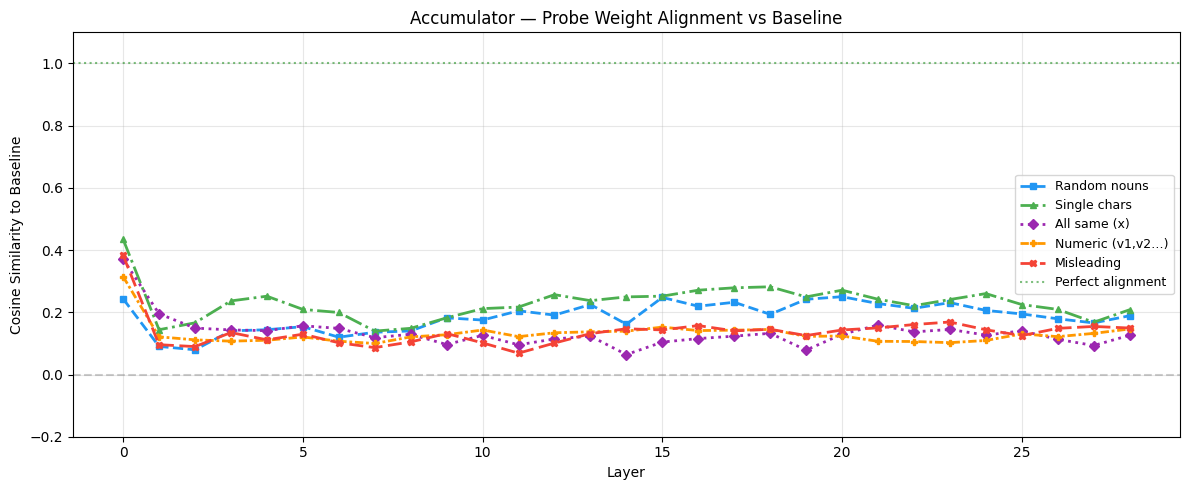


Strategy             Best L   Test Acc   Test F1      Δ F1
----------------------------------------------------------
baseline                  9      0.984     0.893         —
random_nouns             10      0.979     0.870    -0.023
single_chars              9      0.971     0.840    -0.053
all_same                  5      0.986     0.969    +0.076
numeric_vars              3      0.999     0.986    +0.093
misleading                9      0.996     0.972    +0.079


: 

In [13]:
# Cosine similarity of probe weights vs baseline
fig, ax = plt.subplots(figsize=(12, 5))
for s, res in all_results.items():
    if s == 'baseline': continue
    sims = [np.dot(all_results['baseline'][l]['probe'].coef_[0], res[l]['probe'].coef_[0]) /
            (norm(all_results['baseline'][l]['probe'].coef_[0]) * norm(res[l]['probe'].coef_[0]))
            for l in layers]
    ax.plot(layers, sims, marker=MARKERS[s], color=COLORS[s], linestyle=LSTYLES[s],
            linewidth=2, markersize=5, label=PLABELS[s])
ax.axhline(1.0, color='green', linestyle=':', alpha=0.5, label='Perfect alignment')
ax.axhline(0.0, color='gray',  linestyle='--', alpha=0.4)
ax.set_xlabel('Layer'); ax.set_ylabel('Cosine Similarity to Baseline')
ax.set_title('Accumulator — Probe Weight Alignment vs Baseline')
ax.set_ylim(-0.2, 1.1); ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/cosine_similarity_accumulator.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
base_best_acc = max(all_results['baseline'][l]['test_acc'] for l in layers)
base_best_f1  = max(all_results['baseline'][l]['test_f1']  for l in layers)
print(f'\n{"Strategy":18s}  {"Best L":>7}  {"Test Acc":>9}  {"Test F1":>8}  {"Δ F1":>8}')
print('-' * 58)
for s, res in all_results.items():
    best_l = max(res, key=lambda l: res[l]['test_f1'])
    f1 = res[best_l]['test_f1']; acc = res[best_l]['test_acc']
    delta = f'{f1-base_best_f1:+.3f}' if s != 'baseline' else '—'
    print(f'{s:18s}  {best_l:>7d}  {acc:>9.3f}  {f1:>8.3f}  {delta:>8}')

## Cross-Language Generalization

In [14]:
_C_KW = {'int','long','char','short','float','double','unsigned','void','size_t','bool','true','false','null','NULL'}
_JAVA_KW = {'int','long','char','byte','short','boolean','float','double','String','Integer','Long','Object','null','true','false'}
_CS_KW   = {'int','long','char','byte','short','bool','float','double','string','object','null','true','false','var'}
_JS_KW   = {'undefined','null','true','false','NaN','Infinity','length','prototype','constructor'}

_AUG_RE  = re.compile(r'\b([a-zA-Z_]\w*)\s*(?:\+=|-=|\*=|/=|\|=|&=|\^=)')
_INC_RE  = re.compile(r'\b([a-zA-Z_]\w*)\s*(?:\+\+|--)')
_APP_RE  = re.compile(r'\b([a-zA-Z_]\w*)\.(?:add|push|append|extend|offer)\s*\(')

def _accum_re(code, ex=None):
    c = set()
    for p in [_AUG_RE, _INC_RE, _APP_RE]: [c.add(m.group(1)) for m in p.finditer(code)]
    return c - (ex or set())

LANG_EXTRACTORS = {
    'Java':       lambda c: _accum_re(c, _JAVA_KW),
    'C++':        lambda c: _accum_re(c, _C_KW),
    'C':          lambda c: _accum_re(c, _C_KW),
    'C#':         lambda c: _accum_re(c, _CS_KW),
    'Javascript': lambda c: _accum_re(c, _JS_KW),
    'PHP':        lambda c: _accum_re(re.sub(r'\$([a-zA-Z_]\w*)', r'\1', c)),
}
LANG_COLORS = {'Java':'#FF9800','C++':'#2196F3','C':'#4CAF50','C#':'#9C27B0','Javascript':'#F44336','PHP':'#795548'}

py_results = all_results['baseline']
# py_hidden is not used in cross-lang; guard against missing key when loaded from checkpoint
py_hidden  = all_hidden.get('baseline', {})
py_labels  = all_labels.get('baseline', np.array([]))

lang_cross, lang_cosine_cl, lang_results_cl = {}, {}, {}

for lang, extractor in LANG_EXTRACTORS.items():
    print(f'\n{"─"*50}  {lang}')
    try: programs = load_programs(lang, n=300)
    except FileNotFoundError as e: print(f'  Skip — {e}'); continue

    data, skipped = [], 0
    for code in programs:
        names = extractor(code)
        if not names: skipped += 1; continue
        toks, labs = label_tokens(code, names)
        if toks and sum(labs) > 0: data.append({'code': code, 'tokens': toks, 'labels': labs, 'target_names': names})
        else: skipped += 1
    print(f'  {len(data)} programs  ({skipped} skipped)')
    if not data: continue

    lh, ll, _ = extract_hidden_states(data)
    print(f'  tokens={len(ll):,}  pos={int(sum(ll)):,}')

    lang_cross[lang] = {li: accuracy_score(ll, py_results[li]['probe'].predict(lh[li]))
                        for li in sorted(py_results) if li in lh}

    if len(ll) >= 20 and sum(ll) >= 5:
        lp = train_probes(lh, ll)
        lang_results_cl[lang] = lp
        lang_cosine_cl[lang]  = [
            np.dot(py_results[li]['probe'].coef_[0], lp[li]['probe'].coef_[0]) /
            (norm(py_results[li]['probe'].coef_[0]) * norm(lp[li]['probe'].coef_[0]))
            for li in sorted(py_results) if li in lp
        ]
        best_l = max(lp, key=lambda l: lp[l]['test_f1'])
        print(f'  In-domain F1={lp[best_l]["test_f1"]:.3f} (L{best_l})  '
              f'Cross-acc={max(lang_cross[lang].values()):.3f}')

print('\nCross-language done:', list(lang_cross.keys()))


──────────────────────────────────────────────────  Java
  208 programs  (92 skipped)


Extracting hidden states: 100%|██████████| 208/208 [20:18<00:00,  5.86s/it]


  tokens=46,972  pos=2,625


Training probes: 100%|██████████| 29/29 [05:22<00:00, 11.13s/it]


  In-domain F1=0.952 (L9)  Cross-acc=0.948

──────────────────────────────────────────────────  C++
  204 programs  (96 skipped)


Extracting hidden states: 100%|██████████| 204/204 [19:14<00:00,  5.66s/it]


In [ ]:
if lang_cross:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    ax = axes[0]
    ax.plot(layers, [py_results[l]['test_acc'] for l in layers],
            marker='o', color='#FF5722', linewidth=2, label='Python (test)')
    for lang, ca in lang_cross.items():
        ll = sorted(ca); ax.plot(ll, [ca[l] for l in ll], marker='s', linestyle='--',
                                  linewidth=2, color=LANG_COLORS[lang], label=f'{lang} (cross-lang)')
    ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5)
    ax.set_xlabel('Layer'); ax.set_ylabel('Accuracy'); ax.set_ylim(0.4, 1.05)
    ax.set_title('Cross-Language Generalization'); ax.legend(fontsize=9); ax.grid(alpha=0.3)

    ax = axes[1]
    for lang, sims in lang_cosine_cl.items():
        ll = sorted(py_results)[:len(sims)]
        ax.plot(ll, sims, marker='s', linewidth=2, color=LANG_COLORS[lang], label=lang)
    ax.axhline(1.0, color='green', linestyle=':', alpha=0.5, label='Perfect alignment')
    ax.axhline(0.0, color='gray',  linestyle='--', alpha=0.4)
    ax.set_xlabel('Layer'); ax.set_ylabel('Cosine Sim (Python vs Lang Probe)')
    ax.set_ylim(-0.2, 1.1); ax.set_title('Cross-Language Probe Alignment')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

    plt.suptitle('Accumulator Probe — Cross-Language', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/cross_language_accumulator.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {RESULTS_DIR}/cross_language_accumulator.png')

## Multi-Model Comparison

In [ ]:
from transformers import AutoTokenizer as _Tok, AutoModel as _Mdl

ADDITIONAL_MODELS = {
    'CodeBERT':     'microsoft/codebert-base',
    'RoBERTa':      'roberta-base',
    'Qwen2.5-0.5B': 'Qwen/Qwen2.5-0.5B',
}

def _run_model(model_name, dataset):
    tok = _Tok.from_pretrained(model_name, trust_remote_code=True)
    if tok.pad_token_id is None: tok.pad_token = tok.eos_token
    mdl = _Mdl.from_pretrained(model_name, output_hidden_states=True, trust_remote_code=True)
    mdl.eval().to(DEVICE)
    leading = len(tok('x', return_tensors='pt')['input_ids'][0]) - len(tok.tokenize('x'))

    relabeled = []
    for s in dataset:
        toks = tok.tokenize(s['code']); labs = []
        for t in toks:
            clean = t.lstrip('Ġ▁Ā').lstrip('##')
            labs.append(1 if (not t.startswith('##') and
                              (clean in s['target_names'] or clean.strip('[]().,;:') in s['target_names'])) else 0)
        if toks and sum(labs) > 0: relabeled.append({**s, 'tokens': toks, 'labels': labs})

    all_h, all_l = defaultdict(list), []
    with torch.no_grad():
        for s in tqdm(relabeled, desc=f'  {model_name.split("/")[-1]}', leave=False):
            enc = tok(s['code'], return_tensors='pt', truncation=True,
                      max_length=512, padding=False).to(DEVICE)
            enc_len = enc['input_ids'].shape[1] - leading
            labs_t  = s['labels'][:enc_len]
            for li, hs in enumerate(mdl(**enc).hidden_states):
                # .float() required for BFloat16 models
                all_h[li].extend(hs[0, leading:leading+len(labs_t)].cpu().float().numpy())
            all_l.extend(labs_t)

    del mdl
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    h = {k: np.array(v) for k,v in all_h.items()}
    lbs = np.array(all_l)
    return train_probes(h, lbs), h, lbs


# Rebuild baseline dataset for multi-model (targets needed for relabeling)
_bds = []
for code in RAW_PROGRAMS:
    names = get_accumulator_names(code)
    if not names: continue
    toks, labs = label_tokens(code, names)
    if toks and sum(labs) > 0: _bds.append({'code': code, 'tokens': toks, 'labels': labs, 'target_names': names})
print(f'Baseline dataset for multi-model: {len(_bds)} programs')

# If hidden states not in memory (loaded from checkpoint), re-extract Qwen2.5-1.5B baseline
if 'baseline' not in all_hidden:
    print('Re-extracting Qwen2.5-1.5B baseline hidden states (not in memory after checkpoint load)...')
    _bh, _bl, _ = extract_hidden_states(_bds)
    all_hidden['baseline'] = _bh
    all_labels['baseline'] = _bl

mm_results = {'Qwen2.5-1.5B': all_results['baseline']}
mm_hidden  = {'Qwen2.5-1.5B': all_hidden['baseline']}
mm_labels  = {'Qwen2.5-1.5B': all_labels['baseline']}

for nick, mname in ADDITIONAL_MODELS.items():
    print(f'\n{"─"*50}  {nick}')
    try:
        res, h, lbs = _run_model(mname, _bds)
        mm_results[nick] = res; mm_hidden[nick] = h; mm_labels[nick] = lbs
        best_l = max(res, key=lambda l: res[l]['test_f1'])
        print(f'  L{best_l}  F1={res[best_l]["test_f1"]:.3f}  Acc={res[best_l]["test_acc"]:.3f}')
    except Exception as e:
        print(f'  FAILED: {e}')

print('\nModels done:', list(mm_results.keys()))

In [ ]:
MC = ['#FF5722','#2196F3','#4CAF50','#9C27B0','#FF9800','#00BCD4']
MM = ['o','s','^','D','P','X']
layers_mm = sorted(next(iter(mm_results.values())).keys())

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, metric, ylabel in zip(axes, ['test_acc','test_f1'], ['Test Accuracy','Test Macro F1']):
    for i, (nick, res) in enumerate(mm_results.items()):
        ax.plot(layers_mm, [res[l][metric] for l in layers_mm],
                marker=MM[i%len(MM)], color=MC[i%len(MC)], linewidth=2, markersize=5, label=nick)
    ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5)
    ax.set_xlabel('Layer'); ax.set_ylabel(ylabel); ax.set_ylim(0.3, 1.05)
    ax.set_title(f'Accumulator — {ylabel} (All Models)'); ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/multi_model_accumulator.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n{"Model":25s}  {"Best L":>7}  {"Test Acc":>9}  {"Test F1":>8}')
print('-' * 55)
for nick, res in mm_results.items():
    bl = max(res, key=lambda l: res[l]['test_f1'])
    print(f'{nick:25s}  {bl:>7d}  {res[bl]["test_acc"]:>9.3f}  {res[bl]["test_f1"]:>8.3f}')

## Cross-Model Transfer Matrix

In [ ]:
nicks = list(mm_results.keys()); N = len(nicks)
xfer  = np.zeros((N, N))
for i, src in enumerate(nicks):
    for j, tgt in enumerate(nicks):
        if src not in mm_hidden or tgt not in mm_hidden: xfer[i,j] = np.nan; continue
        bl  = max(mm_results[src], key=lambda l: mm_results[src][l]['test_f1'])
        tl  = min(mm_hidden[tgt], key=lambda l: abs(l - bl))
        xfer[i,j] = f1_score(mm_labels[tgt], mm_results[src][bl]['probe'].predict(mm_hidden[tgt][tl]),
                             average='macro', zero_division=0)

fig, ax = plt.subplots(figsize=(max(6,N*2), max(5,N*1.6)))
im = ax.imshow(np.where(np.isnan(xfer), 0, xfer), cmap='YlOrRd', vmin=0.5, vmax=1.0)
ax.set_xticks(range(N)); ax.set_xticklabels(nicks, rotation=20, ha='right', fontsize=9)
ax.set_yticks(range(N)); ax.set_yticklabels(nicks, fontsize=9)
ax.set_xlabel('Test Model'); ax.set_ylabel('Train Model')
ax.set_title('Accumulator — Cross-Model Transfer F1')
for i in range(N):
    for j in range(N):
        v = xfer[i,j]
        ax.text(j, i, f'{v:.3f}' if not np.isnan(v) else 'N/A',
                ha='center', va='center', fontsize=9, color='black' if v < 0.8 else 'white')
plt.colorbar(im, ax=ax, label='F1', fraction=0.04, pad=0.02)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/cross_model_transfer_accumulator.png', dpi=150, bbox_inches='tight')
plt.show()

## Save CSVs

In [ ]:
# Per-layer perturbation results
with open(f'{RESULTS_DIR}/per_layer_results.csv', 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['strategy','layer','train_acc','test_acc','train_f1','test_f1'])
    for s, res in all_results.items():
        for l in layers:
            r = res[l]
            w.writerow([s, l, f'{r["train_acc"]:.4f}', f'{r["test_acc"]:.4f}',
                        f'{r["train_f1"]:.4f}', f'{r["test_f1"]:.4f}'])

# Perturbation summary
with open(f'{RESULTS_DIR}/summary_perturbations.csv', 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['strategy','best_layer','best_acc','best_f1','delta_f1'])
    for s, res in all_results.items():
        bl = max(res, key=lambda l: res[l]['test_f1'])
        w.writerow([s, bl, f'{res[bl]["test_acc"]:.4f}', f'{res[bl]["test_f1"]:.4f}',
                    f'{res[bl]["test_f1"]-base_best_f1:.4f}' if s != 'baseline' else ''])

# Cross-language summary
if lang_cross:
    with open(f'{RESULTS_DIR}/summary_cross_language.csv', 'w', newline='') as f:
        w = csv.writer(f)
        w.writerow(['language','best_cross_acc','in_domain_f1','mean_cosine'])
        w.writerow(['Python', f'{base_best_acc:.4f}', f'{base_best_f1:.4f}', ''])
        for lang in LANG_EXTRACTORS:
            if lang not in lang_cross: continue
            in_f1 = max(lang_results_cl[lang][l]['test_f1'] for l in lang_results_cl[lang]) if lang in lang_results_cl else ''
            cos   = f'{np.mean(lang_cosine_cl[lang]):.4f}' if lang in lang_cosine_cl else ''
            w.writerow([lang, f'{max(lang_cross[lang].values()):.4f}',
                        f'{in_f1:.4f}' if in_f1 != '' else '', cos])

# Multi-model summary
with open(f'{RESULTS_DIR}/summary_multi_model.csv', 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['model','best_layer','best_acc','best_f1'])
    for nick, res in mm_results.items():
        bl = max(res, key=lambda l: res[l]['test_f1'])
        w.writerow([nick, bl, f'{res[bl]["test_acc"]:.4f}', f'{res[bl]["test_f1"]:.4f}'])

print('Saved to', RESULTS_DIR)
for fn in sorted(os.listdir(RESULTS_DIR)):
    print(f'  {fn}')